# 简介

第 16 章介绍的 PETS 算法是基于模型的强化学习算法中的一种，它没有显式构建一个策略（即一个从状态到动作的映射函数）。

回顾一下之前介绍过的 Dyna-Q 算法，它也是一种基于模型的强化学习算法。**但是 Dyna-Q 算法中的模型只存储之前遇到的数据，只适用于表格型环境。** 

**而在连续型状态和动作的环境中，我们需要像 PETS 算法一样学习一个用神经网络表示的环境模型，** 
- 此时若继续利用 Dyna 的思想，可以在任意状态和动作下用环境模型来生成一些虚拟数据，这些虚拟数据可以帮助进行策略的学习。
- **如此，通过和模型进行交互产生额外的虚拟数据，对真实环境中样本的需求量就会减少，因此通常会比无模型的强化学习方法具有更高的采样效率。**

本章将介绍这样一种算法——MBPO 算法。

## MBPO 算法

基于模型的策略优化 (model-based policy optimization，MBPO）算法是加州大学伯克利分校的研究员在 2019 年的 NeurIPS 会议中提出的。随即 MBPO 成为深度强化学习中最重要的基于模型的强化学习算法之一。

**MBPO 算法基于以下两个关键的观察：**
- (1) 随着环境模型的推演步数变长，模型累积的复合误差会快速增加，使得环境模型得出的结果变得很不可靠； 
- (2) 必须要权衡**推演步数增加**后模型增加的误差带来的**负面作用**与步数增加后使得训练的策略更优的**正面作用**，
- (3)<font color='red'>二者的权衡决定了推演的步数<font>

#### MBPO 算法在这两个观察的基础之上，**提出
- <font color='blue'>只使用模型来从之前访问过的真实状态开始进行较短步数的推演，<font>
- 而非从初始状态开始进行完整的推演 

这就是 **MBPO 中的分支推演（branched rollout）的概念**：
- 即**在原来真实环境中采样的轨迹上面推演出新的“短分支”**，
- 如图 17-1 所示。这样做可以使模型的累积误差不至于过大，从而保证最后的采样效率和策略表现。

In [1]:
from IPython.display import  Image

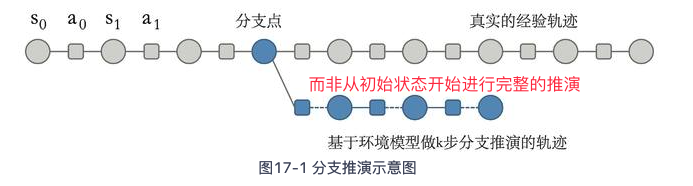

In [4]:
Image(filename='./image/mbpo01.png',width=600)

MBPO 与第 6 章讲解的经典的 Dyna-Q 算法十分类似。
- Dyna-Q 采用的无模型强化学习部分是 Q-learning，
- 而 MBPO 采用的是 SAC。

此外，MBPO 算法中环境模型的构建和 PETS 算法中一致，都使用模型集成的方式，并且其中每一个环境模型的输出都是一个高斯分布。

### 接下来，我们来看一下 MBPO 的具体算法框架。

- MBPO 算法会**把真实环境样本作为分支推演的起点**，使用模型进行一定步数的推演，并用推演得到的模型数据用来训练模型。

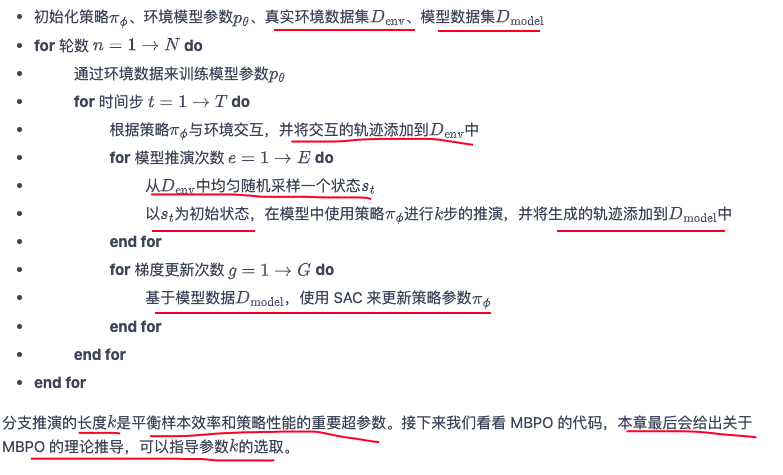

In [3]:
Image(filename='./image/mbpo_step.png',width=600)

# MBPO代码实践

In [8]:
import gym
from collections import namedtuple
import itertools
from itertools import count
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions.normal import Normal
import numpy as np
import collections
import random
import matplotlib.pyplot as plt

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


#### MBPO 算法使用 SAC 算法来训练策略。

- 和 SAC 算法相比，MBPO **多用了一些模型推演得到的数据来训练策略**。

- 要想了解 SAC 方法的详细过程，读者可以阅读第 14 章对应的内容。

我们将 SAC 代码直接复制到此处。

In [9]:
class PolicyNet(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim, action_bound):
        super(PolicyNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc_mu = torch.nn.Linear(hidden_dim, action_dim)
        self.fc_std = torch.nn.Linear(hidden_dim, action_dim)
        self.action_bound = action_bound

    def forward(self, x):
        x = F.relu(self.fc1(x))
        mu = self.fc_mu(x)
        std = F.softplus(self.fc_std(x))
        dist = Normal(mu, std)
        normal_sample = dist.rsample()  # rsample()是重参数化采样函数
        log_prob = dist.log_prob(normal_sample)
        action = torch.tanh(normal_sample)  # 计算tanh_normal分布的对数概率密度
        log_prob = log_prob - torch.log(1 - torch.tanh(action).pow(2) + 1e-7)
        action = action * self.action_bound
        return action, log_prob


class QValueNet(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(QValueNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim + action_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x, a):
        cat = torch.cat([x, a], dim=1)  # 拼接状态和动作
        x = F.relu(self.fc1(cat))
        return self.fc2(x)


device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")


class SAC:
    ''' 处理连续动作的SAC算法 '''
    def __init__(self, state_dim, hidden_dim, action_dim, action_bound,
                 actor_lr, critic_lr, alpha_lr, target_entropy, tau, gamma):
        # 策略网络
        self.actor = PolicyNet(state_dim, hidden_dim, action_dim,action_bound).to(device) 
        # 第一个Q网络
        self.critic_1 = QValueNet(state_dim, hidden_dim, action_dim).to(device)
        # 第二个Q网络
        self.critic_2 = QValueNet(state_dim, hidden_dim, action_dim).to(device)
        
        self.target_critic_1 = QValueNet(state_dim, hidden_dim,action_dim).to(device)  # 第一个目标Q网络
        self.target_critic_2 = QValueNet(state_dim, hidden_dim,action_dim).to(device)  # 第二个目标Q网络
        
        # 令目标Q网络的初始参数和Q网络一样
        self.target_critic_1.load_state_dict(self.critic_1.state_dict())
        self.target_critic_2.load_state_dict(self.critic_2.state_dict())
        
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(),lr=actor_lr)
        self.critic_1_optimizer = torch.optim.Adam(self.critic_1.parameters(),lr=critic_lr)
        self.critic_2_optimizer = torch.optim.Adam(self.critic_2.parameters(),lr=critic_lr)
        
        # 使用alpha的log值,可以使训练结果比较稳定
        self.log_alpha = torch.tensor(np.log(0.01), dtype=torch.float)
        self.log_alpha.requires_grad = True  # 可以对alpha求梯度
        self.log_alpha_optimizer = torch.optim.Adam([self.log_alpha],lr=alpha_lr)
        self.target_entropy = target_entropy  # 目标熵的大小
        self.gamma = gamma
        self.tau = tau

    def take_action(self, state):
        state = torch.tensor([state], dtype=torch.float).to(device)
        action = self.actor(state)[0]
        return [action.item()]
    
    # 计算目标Q值
    def calc_target(self, rewards, next_states, dones): 
        next_actions, log_prob = self.actor(next_states)
        entropy = -log_prob
        
        q1_value = self.target_critic_1(next_states, next_actions)
        q2_value = self.target_critic_2(next_states, next_actions)
        
        next_value = torch.min(q1_value,q2_value) + self.log_alpha.exp() * entropy
        
        td_target = rewards + self.gamma * next_value * (1 - dones)
        return td_target

    def soft_update(self, net, target_net):
        for param_target, param in zip(target_net.parameters(),net.parameters()):
            param_target.data.copy_(param_target.data * (1.0 - self.tau) +param.data * self.tau)

    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'],dtype=torch.float).to(device)
        actions = torch.tensor(transition_dict['actions'],dtype=torch.float).view(-1, 1).to(device)
        rewards = torch.tensor(transition_dict['rewards'],dtype=torch.float).view(-1, 1).to(device)
        next_states = torch.tensor(transition_dict['next_states'],dtype=torch.float).to(device)
        dones = torch.tensor(transition_dict['dones'],dtype=torch.float).view(-1, 1).to(device)
        rewards = (rewards + 8.0) / 8.0  # 对倒立摆环境的奖励进行重塑

        # 更新两个Q网络
        td_target = self.calc_target(rewards, next_states, dones)
        critic_1_loss = torch.mean(
            F.mse_loss(self.critic_1(states, actions), td_target.detach()))
        critic_2_loss = torch.mean(
            F.mse_loss(self.critic_2(states, actions), td_target.detach()))
        
        self.critic_1_optimizer.zero_grad()
        critic_1_loss.backward()
        self.critic_1_optimizer.step()
        
        self.critic_2_optimizer.zero_grad()
        critic_2_loss.backward()
        self.critic_2_optimizer.step()

        # 更新策略网络
        new_actions, log_prob = self.actor(states)
        entropy = -log_prob
        q1_value = self.critic_1(states, new_actions)
        q2_value = self.critic_2(states, new_actions)
        actor_loss = torch.mean(-self.log_alpha.exp() * entropy -
                                torch.min(q1_value, q2_value))
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # 更新alpha值
        alpha_loss = torch.mean(
            (entropy - self.target_entropy).detach() * self.log_alpha.exp())
        self.log_alpha_optimizer.zero_grad()
        alpha_loss.backward()
        self.log_alpha_optimizer.step()

        self.soft_update(self.critic_1, self.target_critic_1)
        self.soft_update(self.critic_2, self.target_critic_2)

### 接下来定义环境模型，

注意这里的环境模型和 PETS 算法中的环境模型是一样的，**由多个高斯分布策略的集成来构建**。

我们也沿用 PETS 算法中的模型构建代码。

In [10]:
class Swish(nn.Module):
    ''' Swish激活函数 '''
    def __init__(self):
        super(Swish, self).__init__()

    def forward(self, x):
        return x * torch.sigmoid(x)


def init_weights(m):
    ''' 初始化模型权重 '''
    def truncated_normal_init(t, mean=0.0, std=0.01):
        torch.nn.init.normal_(t, mean=mean, std=std)
        while True:
            cond = (t < mean - 2 * std) | (t > mean + 2 * std)
            if not torch.sum(cond):
                break
            t = torch.where(
                cond,
                torch.nn.init.normal_(torch.ones(t.shape, device=device),
                                      mean=mean,
                                      std=std), t)
        return t

    if type(m) == nn.Linear or isinstance(m, FCLayer):
        truncated_normal_init(m.weight, std=1 / (2 * np.sqrt(m._input_dim)))
        m.bias.data.fill_(0.0)


class FCLayer(nn.Module):
    ''' 集成之后的全连接层 '''
    def __init__(self, input_dim, output_dim, ensemble_size, activation):
        super(FCLayer, self).__init__()
        self._input_dim, self._output_dim = input_dim, output_dim
        self.weight = nn.Parameter(
            torch.Tensor(ensemble_size, input_dim, output_dim).to(device))
        self._activation = activation
        self.bias = nn.Parameter(
            torch.Tensor(ensemble_size, output_dim).to(device))

    def forward(self, x):
        return self._activation(
            torch.add(torch.bmm(x, self.weight), self.bias[:, None, :]))

### 接着，我们就可以定义集成模型了，

其中就会用到刚刚定义的全连接层。

In [ ]:
''' 环境模型集成 '''
class EnsembleModel(nn.Module):
    def __init__(self,
                 state_dim,
                 action_dim,
                 model_alpha,
                 ensemble_size=5,
                 learning_rate=1e-3):
        super(EnsembleModel, self).__init__()
        # 输出包括均值和方差,因此是状态与奖励维度之和的两倍
        self._output_dim = (state_dim + 1) * 2
        self._model_alpha = model_alpha  # 模型损失函数中加权时的权重
        self._max_logvar = nn.Parameter((torch.ones(
            (1, self._output_dim // 2)).float() / 2).to(device),
                                        requires_grad=False)
        self._min_logvar = nn.Parameter((-torch.ones(
            (1, self._output_dim // 2)).float() * 10).to(device),
                                        requires_grad=False)

        self.layer1 = FCLayer(state_dim + action_dim, 200, ensemble_size,
                              Swish())
        self.layer2 = FCLayer(200, 200, ensemble_size, Swish())
        self.layer3 = FCLayer(200, 200, ensemble_size, Swish())
        self.layer4 = FCLayer(200, 200, ensemble_size, Swish())
        self.layer5 = FCLayer(200, self._output_dim, ensemble_size,
                              nn.Identity())
        self.apply(init_weights)  # 初始化环境模型中的参数
        self.optimizer = torch.optim.Adam(self.parameters(), lr=learning_rate)

    def forward(self, x, return_log_var=False):
        ret = self.layer5(self.layer4(self.layer3(self.layer2(
            self.layer1(x)))))
        mean = ret[:, :, :self._output_dim // 2]
        # 在PETS算法中,将方差控制在最小值和最大值之间
        logvar = self._max_logvar - F.softplus(
            self._max_logvar - ret[:, :, self._output_dim // 2:])
        logvar = self._min_logvar + F.softplus(logvar - self._min_logvar)
        return mean, logvar if return_log_var else torch.exp(logvar)

    def loss(self, mean, logvar, labels, use_var_loss=True):
        inverse_var = torch.exp(-logvar)
        if use_var_loss:
            mse_loss = torch.mean(torch.mean(torch.pow(mean - labels, 2) *
                                             inverse_var,
                                             dim=-1),
                                  dim=-1)
            var_loss = torch.mean(torch.mean(logvar, dim=-1), dim=-1)
            total_loss = torch.sum(mse_loss) + torch.sum(var_loss)
        else:
            mse_loss = torch.mean(torch.pow(mean - labels, 2), dim=(1, 2))
            total_loss = torch.sum(mse_loss)
        return total_loss, mse_loss

    def train(self, loss):
        self.optimizer.zero_grad()
        loss += self._model_alpha * torch.sum(
            self._max_logvar) - self._model_alpha * torch.sum(self._min_logvar)
        loss.backward()
        self.optimizer.step()
        

''' 环境模型集成,加入精细化的训练 '''
class EnsembleDynamicsModel:
    def __init__(self, state_dim, action_dim, model_alpha=0.01, num_network=5):
        self._num_network = num_network
        self._state_dim, self._action_dim = state_dim, action_dim
        self.model = EnsembleModel(state_dim,
                                   action_dim,
                                   model_alpha,
                                   ensemble_size=num_network)
        self._epoch_since_last_update = 0

    def train(self,
              inputs,
              labels,
              batch_size=64,
              holdout_ratio=0.1,
              max_iter=20):
        # 设置训练集与验证集
        permutation = np.random.permutation(inputs.shape[0])
        inputs, labels = inputs[permutation], labels[permutation]
        num_holdout = int(inputs.shape[0] * holdout_ratio)
        train_inputs, train_labels = inputs[num_holdout:], labels[num_holdout:]
        holdout_inputs, holdout_labels = inputs[:
                                                num_holdout], labels[:
                                                                     num_holdout]
        holdout_inputs = torch.from_numpy(holdout_inputs).float().to(device)
        holdout_labels = torch.from_numpy(holdout_labels).float().to(device)
        holdout_inputs = holdout_inputs[None, :, :].repeat(
            [self._num_network, 1, 1])
        holdout_labels = holdout_labels[None, :, :].repeat(
            [self._num_network, 1, 1])

        # 保留最好的结果
        self._snapshots = {i: (None, 1e10) for i in range(self._num_network)}

        for epoch in itertools.count():
            # 定义每一个网络的训练数据
            train_index = np.vstack([
                np.random.permutation(train_inputs.shape[0])
                for _ in range(self._num_network)
            ])
            # 所有真实数据都用来训练
            for batch_start_pos in range(0, train_inputs.shape[0], batch_size):
                batch_index = train_index[:, batch_start_pos:batch_start_pos +
                                          batch_size]
                train_input = torch.from_numpy(
                    train_inputs[batch_index]).float().to(device)
                train_label = torch.from_numpy(
                    train_labels[batch_index]).float().to(device)

                mean, logvar = self.model(train_input, return_log_var=True)
                loss, _ = self.model.loss(mean, logvar, train_label)
                self.model.train(loss)

            with torch.no_grad():
                mean, logvar = self.model(holdout_inputs, return_log_var=True)
                _, holdout_losses = self.model.loss(mean,
                                                    logvar,
                                                    holdout_labels,
                                                    use_var_loss=False)
                holdout_losses = holdout_losses.cpu()
                break_condition = self._save_best(epoch, holdout_losses)
                if break_condition or epoch > max_iter:  # 结束训练
                    break

    def _save_best(self, epoch, losses, threshold=0.1):
        updated = False
        for i in range(len(losses)):
            current = losses[i]
            _, best = self._snapshots[i]
            improvement = (best - current) / best
            if improvement > threshold:
                self._snapshots[i] = (epoch, current)
                updated = True
        self._epoch_since_last_update = 0 if updated else self._epoch_since_last_update + 1
        return self._epoch_since_last_update > 5

    def predict(self, inputs, batch_size=64):
        inputs = np.tile(inputs, (self._num_network, 1, 1))
        inputs = torch.tensor(inputs, dtype=torch.float).to(device)
        mean, var = self.model(inputs, return_log_var=False)
        return mean.detach().cpu().numpy(), var.detach().cpu().numpy()


class FakeEnv:
    def __init__(self, model):
        self.model = model

    def step(self, obs, act):
        inputs = np.concatenate((obs, act), axis=-1)
        ensemble_model_means, ensemble_model_vars = self.model.predict(inputs)
        ensemble_model_means[:, :, 1:] += obs
        ensemble_model_stds = np.sqrt(ensemble_model_vars)
        ensemble_samples = ensemble_model_means + np.random.normal(
            size=ensemble_model_means.shape) * ensemble_model_stds

        num_models, batch_size, _ = ensemble_model_means.shape
        models_to_use = np.random.choice(
            [i for i in range(self.model._num_network)], size=batch_size)
        batch_inds = np.arange(0, batch_size)
        samples = ensemble_samples[models_to_use, batch_inds]
        rewards, next_obs = samples[:, :1][0][0], samples[:, 1:][0]
        return rewards, next_obs

### 最后，我们来实现 MBPO 算法的具体流程。

In [ ]:
class MBPO:
    def __init__(self, env, agent, fake_env, env_pool, model_pool,
                 rollout_length, rollout_batch_size, real_ratio, num_episode):

        self.env = env
        self.agent = agent
        self.fake_env = fake_env # 环境模型，用于模拟环境的动态。
        self.env_pool = env_pool # 真实环境数据集池
        self.model_pool = model_pool # 模型书集池
        # rollout_length 决定了每个观测值回滚的步数。较长的回滚长度可以生成更长的虚拟轨迹，但计算成本也会增加。
        self.rollout_length = rollout_length # 每个观测值回滚的长度。 
        self.rollout_batch_size = rollout_batch_size # 每次回滚时从环境数据池中采样的观测值数量。
        self.real_ratio = real_ratio
        self.num_episode = num_episode

    # 模型回滚是指使用环境模型（fake_env）来生成虚拟的轨迹数据，这些数据可以用于训练智能体（agent）
    def rollout_model(self):
        observations, _, _, _, _ = self.env_pool.sample(self.rollout_batch_size)
        for obs in observations:
            # 对每个观测值进行 rollout_length 次回滚。
            for i in range(self.rollout_length):
                # 使用智能体 agent 根据当前观测值 obs 选择一个动作 action
                action = self.agent.take_action(obs)
                # 使用环境模型 fake_env 模拟环境的动态
                # 环境模型 fake_env 是一个关键组件，它模拟真实环境的动态。
                # 通过 fake_env.step 方法，可以生成虚拟的轨迹数据。
                reward, next_obs = self.fake_env.step(obs, action)
                # 将生成的虚拟数据（观测值、动作、奖励、下一个观测值、是否终止）存储到模型数据池 model_pool 中
                self.model_pool.add(obs, action, reward, next_obs, False)
                obs = next_obs

    # 智能体（agent）的更新过程。
    # 它结合了从真实环境（env_pool）和环境模型（model_pool）中采样的数据来训练智能体
    def update_agent(self, policy_train_batch_size=64):
        # 从真实环境数据池中采样的数据量
        env_batch_size = int(policy_train_batch_size * self.real_ratio)
        # 从虚拟数据池中采样的数据量
        model_batch_size = policy_train_batch_size - env_batch_size
        for epoch in range(10):
            # 从真实环境数据池中采样
            env_obs, env_action, env_reward, env_next_obs, env_done = self.env_pool.sample(env_batch_size)
            if self.model_pool.size() > 0:
                # 从虚拟数据池中采样
                model_obs, model_action, model_reward, model_next_obs, model_done = self.model_pool.sample(model_batch_size)
                # 将真实数据和虚拟数据合并，形成完整的训练数据集
                obs = np.concatenate((env_obs, model_obs), axis=0)
                action = np.concatenate((env_action, model_action), axis=0)
                next_obs = np.concatenate((env_next_obs, model_next_obs),axis=0)
                reward = np.concatenate((env_reward, model_reward), axis=0)
                done = np.concatenate((env_done, model_done), axis=0)
            else:
                obs, action, next_obs, reward, done = env_obs, env_action, env_next_obs, env_reward, env_done
           
            # 将合并后的数据存储在一个字典中，方便传递给智能体的更新方法。
            transition_dict = {
                'states': obs,
                'actions': action,
                'next_states': next_obs,
                'rewards': reward,
                'dones': done
            }
            # 使用合并后的数据调用智能体的 update 方法，更新智能体的策略
            self.agent.update(transition_dict)
            
    # 环境模型（fake_env.model）的训练过程。
    # 环境模型用于预测给定观测值和动作时的奖励和下一个观测值的变化。
    def train_model(self):
        # 从环境数据池 env_pool 中获取所有样本
        obs, action, reward, next_obs, done = self.env_pool.return_all_samples()
        # 构建输入数据
        # 将观测值 obs 和动作 action 沿最后一个轴（通常是特征轴）连接起来，形成模型的输入数据 inputs
        inputs = np.concatenate((obs, action), axis=-1)
        reward = np.array(reward)
        # 将奖励数据 reward 重塑为 (reward.shape[0], -1) 的形状，确保它是一个二维数组。
        # next_obs - obs：计算下一个观测值 next_obs 与当前观测值 obs 的差值 next_obs - obs，这表示观测值的变化。
        labels = np.concatenate((np.reshape(reward, (reward.shape[0], -1)), next_obs - obs),axis=-1)
        # 使用构建的输入数据 inputs 和标签数据 labels 训练环境模型 fake_env.model
        self.fake_env.model.train(inputs, labels)

    # 智能体（agent）在环境中（env）进行交互，收集数据并存储到数据池（env_pool）中。
    # 这个过程通常用于收集初始数据，以便后续训练智能体或环境模型
    def explore(self):
        obs, done, episode_return = self.env.reset(), False, 0
        while not done:
            action = self.agent.take_action(obs)
            # 与环境交互
            next_obs, reward, done, _ = self.env.step(action)
            # 存储数据到数据池
            self.env_pool.add(obs, action, reward, next_obs, done)
            obs = next_obs
            episode_return += reward
        return episode_return

    # 它结合了探索（exploration）、环境模型训练（model training）、模型回滚（model rollout）和智能体更新（agent update）等多个步骤
    def train(self):
        return_list = []
        explore_return = self.explore()  # 随机探索采取数据
        print('episode: 1, return: %d' % explore_return)
        return_list.append(explore_return)

        for i_episode in range(self.num_episode - 1):
            obs, done, episode_return = self.env.reset(), False, 0
            step = 0
            while not done:
                # 每隔 50 步，训练环境模型并进行模型回滚，生成虚拟数据
                if step % 50 == 0:
                    # 环境模型训练（model training）
                    self.train_model()
                    # 模型回滚（model rollout）
                    self.rollout_model()
                action = self.agent.take_action(obs)
                next_obs, reward, done, _ = self.env.step(action)
                self.env_pool.add(obs, action, reward, next_obs, done)
                obs = next_obs
                episode_return += reward
                
                # 智能体更新（agent update）
                self.update_agent()
                step += 1
            return_list.append(episode_return)
            print('episode: %d, return: %d' % (i_episode + 2, episode_return))
        return return_list


class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = collections.deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def size(self):
        return len(self.buffer)

    def sample(self, batch_size):
        if batch_size > len(self.buffer):
            return self.return_all_samples()
        else:
            transitions = random.sample(self.buffer, batch_size)
            state, action, reward, next_state, done = zip(*transitions)
            return np.array(state), action, reward, np.array(next_state), done

    def return_all_samples(self):
        all_transitions = list(self.buffer)
        state, action, reward, next_state, done = zip(*all_transitions)
        return np.array(state), action, reward, np.array(next_state), done

**对于不同的环境，我们需要设置不同的参数。**

这里以 OpenAI Gym 中的 Pendulum-v0 环境为例，给出一组效果较为不错的参数。

读者可以试着自己调节参数，观察调节后的效果。

In [ ]:
real_ratio = 0.5
env_name = 'Pendulum-v0'
env = gym.make(env_name)
num_episodes = 20
actor_lr = 5e-4
critic_lr = 5e-3
alpha_lr = 1e-3
hidden_dim = 128
gamma = 0.98
tau = 0.005  # 软更新参数
buffer_size = 10000
target_entropy = -1
model_alpha = 0.01  # 模型损失函数中的加权权重

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_bound = env.action_space.high[0]  # 动作最大值

rollout_batch_size = 1000
rollout_length = 1  # 推演长度k,推荐更多尝试
model_pool_size = rollout_batch_size * rollout_length

agent = SAC(state_dim, hidden_dim, action_dim, action_bound, actor_lr,critic_lr, alpha_lr, target_entropy, tau, gamma)

model = EnsembleDynamicsModel(state_dim, action_dim, model_alpha)

fake_env = FakeEnv(model)

env_pool = ReplayBuffer(buffer_size)

model_pool = ReplayBuffer(model_pool_size)

mbpo = MBPO(env, agent, fake_env, env_pool, model_pool, rollout_length,rollout_batch_size, real_ratio, num_episodes)

return_list = mbpo.train()

episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('MBPO on {}'.format(env_name))
plt.show()

In [ ]:
episode: 1, return: -1617
episode: 2, return: -1463
episode: 3, return: -1407
episode: 4, return: -929
episode: 5, return: -860
episode: 6, return: -643
episode: 7, return: -128
episode: 8, return: -368
episode: 9, return: -118
episode: 10, return: -123
episode: 11, return: -122
episode: 12, return: -118
episode: 13, return: -119
episode: 14, return: -119
episode: 15, return: -121
episode: 16, return: -123
episode: 17, return: 0
episode: 18, return: -125
episode: 19, return: -126
episode: 20, return: -243

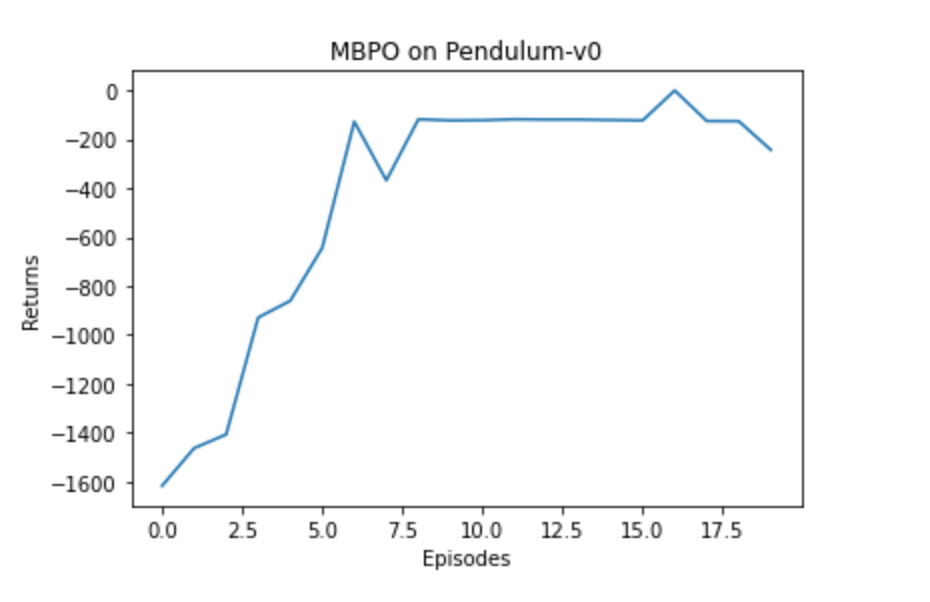

In [5]:
Image(filename='./image/mbpo_chart.png',width=400)

可以看到，相比无模型的强化学习算法，基于模型的方法 MBPO 在样本效率上要高很多。

虽然这里的效果可能不如 16.3 节提到的 PETS 算法优秀，

**但是在许多更加复杂的环境中（如 Hopper 和 HalfCheetah），MBPO 的表现远远好于 PETS 算法。**

**MBPO 算法是一种前沿的基于模型的强化学习算法**:
- 它提出了一个重要的概念——分支推演。

在各种复杂的环境中，作者验证了 MBPO 的效果超过了之前基于模型的方法。

**MBPO 对于基于模型的强化学习的发展起着重要的作用，不少之后的工作都是在此基础上进行的。**

**除了算法的有效性，MBPO 的重要贡献还包括它给出了关于分支推演步数与模型误差、策略偏移程度之间的定量关系，进而阐明了什么时候我们可以相信并使用环境模型，什么样的环境导出的最优分支推演步数为0，进而建议不使用环境模型。**

相应的理论分析在 17.5 节给出。

## MBPO 理论分析

# 参考文献

[1] JANNER M, FU J, ZHANG M, et al. When to trust your model: model-based policy optimization [J]. Advances in neural information processing systems 2019, 32: 12519-12530.